In [1]:
from pathlib import Path
import sys



project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.data_loader import (
    load_market_data,
    calculate_returns,
    summary_statistics
)

In [3]:
TICKERS = [

    "AAPL",
    "MSFT",
    "NVDA",
    "AMD",
    "INTC",
    "GOOGL",

    "JPM",
    "BAC",
    "GS",
    "MS",

    "KO",
    "PEP",
    "MCD",
    "SBUX",

    "XOM",
    "CVX",

    "V",
    "MA"

]

In [4]:
prices = load_market_data(

    tickers=TICKERS,

    start="2015-01-01",

    end="2025-12-31"

)

prices.head()

Ticker,AAPL,AMD,BAC,CVX,GOOGL,GS,INTC,JPM,KO,MA,MCD,MS,MSFT,NVDA,PEP,SBUX,V,XOM
Date,,,,,,,,,,,,,,,,,,
2015-01-02,24.192602,2.67,14.050798,68.898323,26.244781,154.872620,27.896456,46.066792,29.390263,79.714684,69.804451,28.405537,39.681736,0.482423,66.582924,32.260986,61.088097,57.145561
2015-01-05,23.511059,2.66,13.642614,66.144348,25.744717,150.037094,27.581898,44.636639,29.390263,77.472481,69.033516,27.517626,39.316826,0.474275,66.082375,31.643028,59.739647,55.581928
2015-01-06,23.513271,2.63,13.234437,66.113739,25.109348,147.001923,27.067842,43.479267,29.613445,77.304993,69.160759,26.725122,38.739777,0.459896,65.581772,31.385536,59.354710,55.286434
2015-01-07,23.842978,2.58,13.297234,66.058685,25.035505,149.192657,27.635603,43.545597,29.983086,78.507500,70.365822,27.106701,39.231968,0.458697,67.499474,32.158005,60.149948,55.846645
2015-01-08,24.759087,2.61,13.571976,67.570328,25.122730,151.574600,28.149639,44.518692,30.345755,79.728661,70.627792,27.510294,40.386089,0.475952,68.726242,32.676933,60.956730,56.776211


In [5]:
prices.shape

(2765, 18)

In [6]:
returns = calculate_returns(
    prices
)

returns.head()

Ticker,AAPL,AMD,BAC,CVX,GOOGL,GS,INTC,JPM,KO,MA,MCD,MS,MSFT,NVDA,PEP,SBUX,V,XOM
Date,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.003745,-0.029051,-0.039972,-0.019054,-0.031223,-0.011276,-0.031045,0.000000,-0.028128,-0.011044,-0.031258,-0.009196,-0.016890,-0.007518,-0.019155,-0.022074,-0.027362
2015-01-06,0.000094,-0.011278,-0.029919,-0.000463,-0.024680,-0.020229,-0.018637,-0.025929,0.007594,-0.002162,0.001843,-0.028800,-0.014677,-0.030318,-0.007575,-0.008137,-0.006444,-0.005316
2015-01-07,0.014022,-0.019011,0.004745,-0.000833,-0.002941,0.014903,0.020975,0.001526,0.012482,0.015555,0.017424,0.014278,0.012705,-0.002606,0.029241,0.024612,0.013398,0.010133
2015-01-08,0.038423,0.011628,0.020662,0.022883,0.003484,0.015966,0.018601,0.022347,0.012096,0.015555,0.003723,0.014889,0.029418,0.037618,0.018174,0.016137,0.013413,0.016645
2015-01-09,0.001072,0.007663,-0.017930,-0.019926,-0.012211,-0.015347,0.001908,-0.017387,-0.011032,-0.012744,-0.012187,-0.016271,-0.008405,0.004028,-0.006771,-0.032731,-0.014823,-0.001410


In [7]:
summary_statistics(
    prices
)

,Start Price,End Price,Observations,Missing Values
Ticker,,,,
AAPL,24.192602,272.573547,2765,0
AMD,2.670000,215.339996,2765,0
BAC,14.050798,54.685120,2765,0
CVX,68.898323,149.465485,2765,0
GOOGL,26.244781,313.442017,2765,0
GS,154.872620,875.929443,2765,0
INTC,27.896456,37.299999,2765,0
JPM,46.066792,318.891754,2765,0
KO,29.390263,69.145065,2765,0


In [8]:
prices.to_csv("../data/raw/prices.csv")

In [9]:
returns.to_csv("../data/raw/returns.csv")

In [10]:
from src.pair_selection import (
    generate_pairs,
    correlation_matrix,
    rank_pairs,
    top_pairs,
    filter_pairs
)

In [11]:
pairs = generate_pairs(TICKERS)

len(pairs)

153

In [12]:
corr = correlation_matrix(
    returns
)

corr.round(2)



Ticker,AAPL,AMD,BAC,CVX,GOOGL,GS,INTC,JPM,KO,MA,MCD,MS,MSFT,NVDA,PEP,SBUX,V,XOM
Ticker,,,,,,,,,,,,,,,,,,
AAPL,1.00,0.42,0.42,0.34,0.59,0.47,0.45,0.42,0.34,0.58,0.38,0.48,0.66,0.53,0.40,0.45,0.56,0.31
AMD,0.42,1.00,0.29,0.23,0.39,0.33,0.37,0.28,0.14,0.37,0.20,0.34,0.43,0.58,0.17,0.29,0.35,0.19
BAC,0.42,0.29,1.00,0.57,0.40,0.82,0.38,0.88,0.38,0.55,0.40,0.83,0.43,0.33,0.32,0.46,0.56,0.54
CVX,0.34,0.23,0.57,1.00,0.31,0.54,0.33,0.58,0.39,0.47,0.40,0.56,0.34,0.25,0.32,0.37,0.46,0.83
GOOGL,0.59,0.39,0.40,0.31,1.00,0.45,0.41,0.41,0.29,0.54,0.34,0.45,0.68,0.52,0.30,0.42,0.53,0.27
GS,0.47,0.33,0.82,0.54,0.45,1.00,0.43,0.83,0.36,0.57,0.40,0.87,0.48,0.41,0.33,0.48,0.57,0.51
INTC,0.45,0.37,0.38,0.33,0.41,0.43,1.00,0.40,0.26,0.42,0.26,0.43,0.49,0.45,0.31,0.32,0.40,0.30
JPM,0.42,0.28,0.88,0.58,0.41,0.83,0.40,1.00,0.42,0.58,0.44,0.82,0.44,0.34,0.35,0.47,0.58,0.54
KO,0.34,0.14,0.38,0.39,0.29,0.36,0.26,0.42,1.00,0.48,0.52,0.37,0.36,0.16,0.72,0.39,0.47,0.37


In [13]:
ranking = rank_pairs(
    returns
)

ranking.head(20)

,Stock_1,Stock_2,Correlation
0,MA,V,0.895043
1,BAC,JPM,0.884609
2,GS,MS,0.869682
3,BAC,MS,0.834997
4,CVX,XOM,0.834646
5,GS,JPM,0.826742
6,JPM,MS,0.824580
7,BAC,GS,0.818307
8,KO,PEP,0.722520
9,GOOGL,MSFT,0.684288


In [14]:
top_pairs(
    ranking,
    n=10
)

,Stock_1,Stock_2,Correlation
0,MA,V,0.895043
1,BAC,JPM,0.884609
2,GS,MS,0.869682
3,BAC,MS,0.834997
4,CVX,XOM,0.834646
5,GS,JPM,0.826742
6,JPM,MS,0.824580
7,BAC,GS,0.818307
8,KO,PEP,0.722520
9,GOOGL,MSFT,0.684288


In [15]:
filter_pairs(
    ranking,
    minimum_correlation=0.80
)

,Stock_1,Stock_2,Correlation
0,MA,V,0.895043
1,BAC,JPM,0.884609
2,GS,MS,0.869682
3,BAC,MS,0.834997
4,CVX,XOM,0.834646
5,GS,JPM,0.826742
6,JPM,MS,0.824580
7,BAC,GS,0.818307


In [16]:
from src.cointegration import (
    analyze_pairs,
    cointegrated_pairs
)

In [17]:
cointegration_results = analyze_pairs(
    prices,
    ranking
)

In [18]:
cointegration_results.head(20)

,Stock_1,Stock_2,Correlation,Test_Statistic,P_Value,Cointegrated
0,MA,V,0.895043,-4.716585,0.000528,True
1,KO,MSFT,0.359442,-3.987084,0.007492,True
2,GOOGL,MS,0.453545,-3.825331,0.012538,True
3,AAPL,MSFT,0.663191,-3.738540,0.016336,True
4,AMD,MSFT,0.427361,-3.730132,0.016753,True
5,AAPL,KO,0.341547,-3.654057,0.020970,True
6,AAPL,AMD,0.422103,-3.640720,0.021798,True
7,AMD,GOOGL,0.392681,-3.633881,0.022233,True
8,KO,MA,0.482566,-3.567288,0.026879,True
9,KO,V,0.473252,-3.486538,0.033608,True


In [19]:
cointegrated = cointegrated_pairs(
    cointegration_results
)

cointegrated

,Stock_1,Stock_2,Correlation,Test_Statistic,P_Value,Cointegrated
0,MA,V,0.895043,-4.716585,0.000528,True
1,KO,MSFT,0.359442,-3.987084,0.007492,True
2,GOOGL,MS,0.453545,-3.825331,0.012538,True
3,AAPL,MSFT,0.663191,-3.738540,0.016336,True
4,AMD,MSFT,0.427361,-3.730132,0.016753,True
5,AAPL,KO,0.341547,-3.654057,0.020970,True
6,AAPL,AMD,0.422103,-3.640720,0.021798,True
7,AMD,GOOGL,0.392681,-3.633881,0.022233,True
8,KO,MA,0.482566,-3.567288,0.026879,True
9,KO,V,0.473252,-3.486538,0.033608,True


In [20]:
len(cointegrated)

12

In [21]:
cointegration_results.to_csv(
    "../results/cointegration_results.csv",
    index=False
)

print("Cointegration results saved!")

Cointegration results saved!


In [22]:
from src.spread import (
    estimate_hedge_ratio,
    calculate_spread,
    calculate_zscore,
    spread_statistics
)

In [23]:
ma = prices["MA"]

v = prices["V"]

alpha, beta = estimate_hedge_ratio(
    ma,
    v
)

alpha, beta

(np.float64(-33.62239293668108), np.float64(1.7725401163517556))

In [24]:
##### SPREAD
spread = calculate_spread(
    ma,
    v,
    beta,
    alpha
)

spread.head()

Date
2015-01-02    5.055975
2015-01-05    5.203953
2015-01-06    5.718782
2015-01-07    5.511697
2015-01-08    5.302804
dtype: float64

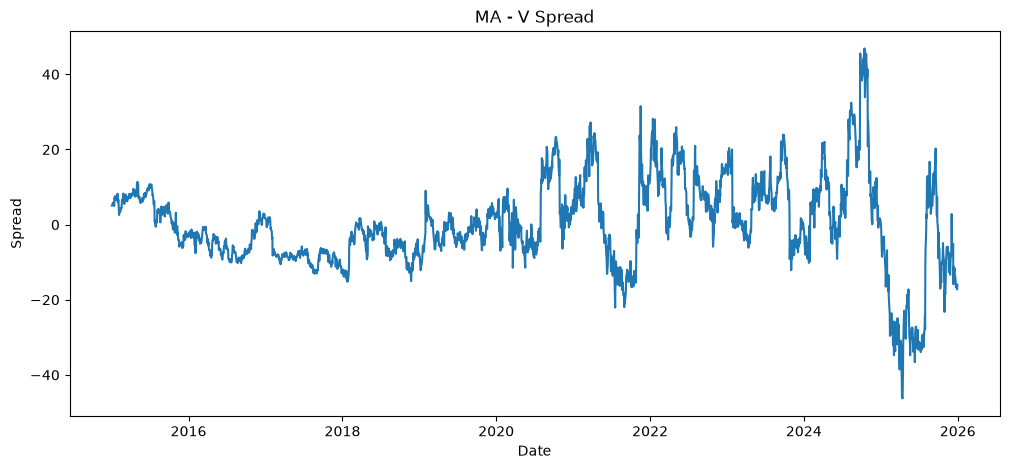

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(spread)

plt.title(
    "MA - V Spread"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Spread"
)

plt.show()

In [26]:
zscore = calculate_zscore(
    spread
)

zscore.tail()

Date
2025-12-23   -1.327782
2025-12-24   -1.295315
2025-12-26   -1.171292
2025-12-29   -1.349349
2025-12-30   -1.040872
dtype: float64

In [27]:
spread_statistics(
    spread
)

,Mean,Std,Min,Max,Last Value
0,2.499877e-14,11.951955,-46.265935,46.887093,-15.997605


In [28]:
from src.spread import (
    estimate_hedge_ratio,
    calculate_spread,
    calculate_zscore,
    spread_statistics,
    calculate_half_life,
    calculate_hurst_exponent
)

In [29]:
half_life = calculate_half_life(
    spread
)

half_life

np.float64(36.24243045708136)

In [30]:
hurst = calculate_hurst_exponent(
    spread
)

hurst

np.float64(0.41376036770475644)

In [31]:
import pandas as pd
pair_summary = pd.DataFrame({

    "Pair": ["MA-V"],

    "Half_Life": [half_life],

    "Hurst": [hurst],

    "Cointegrated": [True],

    "Correlation": [
        0.895043
    ]

})

pair_summary

,Pair,Half_Life,Hurst,Cointegrated,Correlation
0,MA-V,36.24243,0.41376,True,0.895043


In [32]:
from src.signals import (
    generate_signals,
    calculate_position_changes
)

In [33]:
signals = generate_signals(
    zscore
)

signals.head()

,Zscore,Position
Date,,
2015-01-02,NaN,0
2015-01-05,NaN,0
2015-01-06,NaN,0
2015-01-07,NaN,0
2015-01-08,NaN,0


In [34]:
signals["Position"].value_counts()

Position
 0    2432
-1     179
 1     154
Name: count, dtype: int64

In [35]:
trades = calculate_position_changes(
    signals
)

trades[
    trades["Trade"] != 0
].head(20)

,Zscore,Position,Trade
Date,,,
2015-01-02,NaN,0,NaN
2015-05-01,2.371070,-1,-1.0
2015-05-05,1.850744,0,1.0
2015-07-24,-3.850841,1,1.0
2015-08-04,-1.961040,0,-1.0
2015-10-19,-2.614709,1,1.0
2015-10-20,-1.852952,0,-1.0
2015-10-26,-2.564060,1,1.0
2015-10-29,-1.968651,0,-1.0


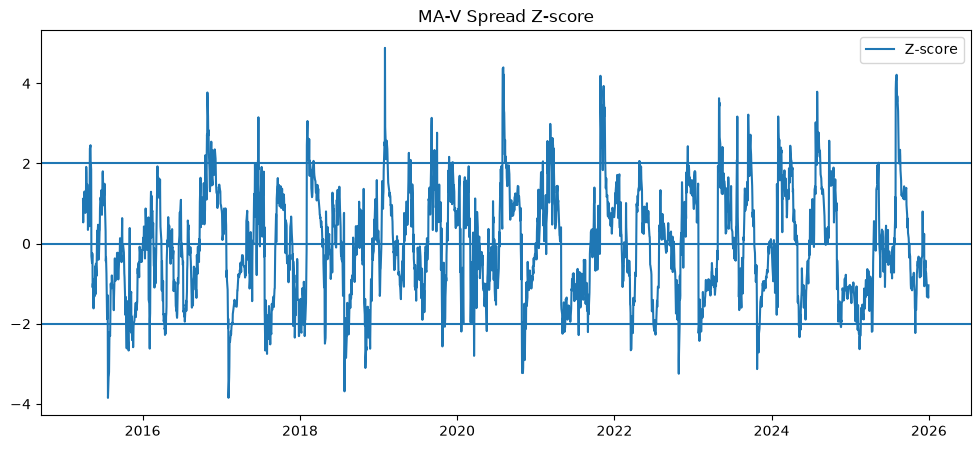

In [36]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

plt.plot(
    zscore,
    label="Z-score"
)

plt.axhline(
    2
)

plt.axhline(
    -2
)

plt.axhline(
    0
)

plt.title(
    "MA-V Spread Z-score"
)

plt.legend()

plt.show()

In [37]:
from src.backtest import (
    calculate_strategy_returns,
    cumulative_returns,
    sharpe_ratio,
    maximum_drawdown,
    performance_summary
)

In [38]:
strategy_returns = calculate_strategy_returns(

    ma,

    v,

    beta,

    signals["Position"]

)

In [39]:
performance_summary(
    strategy_returns
)

,Total Return,Sharpe Ratio,Max Drawdown
0,0.408272,0.421661,-0.116682


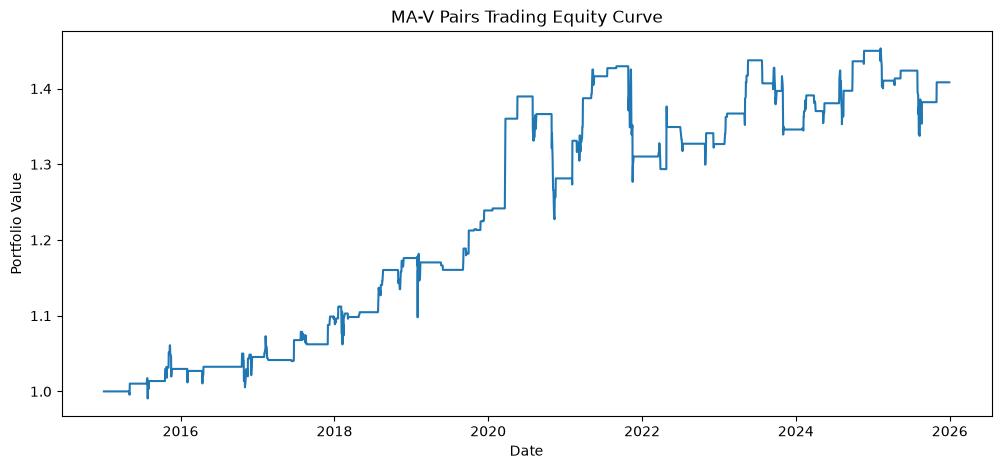

In [40]:
import matplotlib.pyplot as plt


equity_curve = cumulative_returns(
    strategy_returns
)


plt.figure(figsize=(12,5))

plt.plot(
    equity_curve
)

plt.title(
    "MA-V Pairs Trading Equity Curve"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Portfolio Value"
)

plt.show()

In [41]:
from src.costs import apply_transaction_costs

In [42]:
net_returns = apply_transaction_costs(
    strategy_returns,
    signals["Position"]
)

In [43]:
####new performance summary
performance_summary(
    net_returns
)

,Total Return,Sharpe Ratio,Max Drawdown
0,0.128896,0.176785,-0.13311


In [44]:
number_of_trades = (
    signals["Position"]
    .diff()
    .abs()
    .sum()
)

number_of_trades

np.float64(222.0)

In [45]:
##### new signals
signals_05 = generate_signals(
    zscore,
    entry_threshold=2.0,
    exit_threshold=0.5
)

signals_05.head()

,Zscore,Position
Date,,
2015-01-02,NaN,0
2015-01-05,NaN,0
2015-01-06,NaN,0
2015-01-07,NaN,0
2015-01-08,NaN,0


In [46]:
signals_05["Position"].value_counts()

Position
 0    2432
-1     179
 1     154
Name: count, dtype: int64

In [47]:
trades_05 = (
    signals_05["Position"]
    .diff()
    .abs()
    .sum()
)

trades_05

np.float64(222.0)

In [48]:
strategy_returns_05 = calculate_strategy_returns(

    ma,

    v,

    beta,

    signals_05["Position"]

)

In [49]:
net_returns_05 = apply_transaction_costs(

    strategy_returns_05,

    signals_05["Position"]

)

In [50]:
performance_summary(
    net_returns_05
)

,Total Return,Sharpe Ratio,Max Drawdown
0,0.128896,0.176785,-0.13311


In [51]:
(signals["Position"] != signals_05["Position"]).sum()

np.int64(0)

In [52]:
signals_05["Position"].diff().abs().sum()

np.float64(222.0)

In [53]:
from src.research import backtest_pair

In [54]:
result = backtest_pair(
    ma,
    v,
    "MA",
    "V"
)

result

,Total Return,Sharpe Ratio,Max Drawdown,Pair,Trades
0,0.128896,0.176785,-0.13311,MA-V,222.0


In [55]:
from src.research import backtest_pair
import pandas as pd

In [56]:
results = []


for _, row in cointegrated.iterrows():

    stock_1 = row["Stock_1"]
    stock_2 = row["Stock_2"]

    try:

        result = backtest_pair(
            prices[stock_1],
            prices[stock_2],
            stock_1,
            stock_2
        )

        results.append(result)

    except Exception as e:

        print(
            f"Error {stock_1}-{stock_2}: {e}"
        )


pair_results = pd.concat(
    results,
    ignore_index=True
)


pair_results

,Total Return,Sharpe Ratio,Max Drawdown,Pair,Trades
0,0.128896,0.176785,-0.133110,MA-V,222.0
1,-0.292640,-0.340649,-0.393886,KO-MSFT,210.0
2,-0.044453,0.075865,-0.645731,GOOGL-MS,206.0
3,-0.040889,0.008943,-0.415166,AAPL-MSFT,222.0
4,-0.151913,0.025268,-0.538176,AMD-MSFT,198.0
5,-0.542851,0.076971,-0.877276,AAPL-KO,214.0
6,0.464932,0.266868,-0.350788,AAPL-AMD,210.0
7,-0.502340,-0.179480,-0.604696,AMD-GOOGL,202.0
8,0.160753,0.219876,-0.170498,KO-MA,220.0
9,0.132957,0.194298,-0.163902,KO-V,220.0


In [57]:
pair_results_sorted = (
    pair_results
    .sort_values(
        by="Sharpe Ratio",
        ascending=False
    )
)


pair_results_sorted

,Total Return,Sharpe Ratio,Max Drawdown,Pair,Trades
6,0.464932,0.266868,-0.350788,AAPL-AMD,210.0
8,0.160753,0.219876,-0.170498,KO-MA,220.0
9,0.132957,0.194298,-0.163902,KO-V,220.0
0,0.128896,0.176785,-0.133110,MA-V,222.0
5,-0.542851,0.076971,-0.877276,AAPL-KO,214.0
2,-0.044453,0.075865,-0.645731,GOOGL-MS,206.0
4,-0.151913,0.025268,-0.538176,AMD-MSFT,198.0
3,-0.040889,0.008943,-0.415166,AAPL-MSFT,222.0
10,-0.492145,-0.093888,-0.717466,AMD-V,216.0
7,-0.502340,-0.179480,-0.604696,AMD-GOOGL,202.0


In [58]:
pair_results_sorted.to_csv(
    "../data/pair_backtest_results.csv",
    index=False
)

In [59]:
from src.portfolio import equal_weight_portfolio

In [60]:
top_pairs = [
    ("AAPL", "AMD"),
    ("KO", "MA"),
    ("KO", "V"),
    ("MA", "V")
]

In [67]:
portfolio_returns_list = []
portfolio_positions_list = []


for stock_1, stock_2 in top_pairs:

    result = backtest_pair(
        prices[stock_1],
        prices[stock_2],
        stock_1,
        stock_2
    )

    beta = estimate_hedge_ratio(
        prices[stock_1],
        prices[stock_2]
    )[1]


    spread = calculate_spread(
        prices[stock_1],
        prices[stock_2],
        beta
    )


    zscore = calculate_zscore(
        spread
    )


    signals = generate_signals(
        zscore
    )

    portfolio_positions_list.append(
    signals["Position"]
    )



    returns = calculate_strategy_returns(
        prices[stock_1],
        prices[stock_2],
        beta,
        signals["Position"]
    )


    net_returns = apply_transaction_costs(
        returns,
        signals["Position"]
    )


    portfolio_returns_list.append(
        net_returns
    )

In [68]:
portfolio_returns = equal_weight_portfolio(
    portfolio_returns_list
)


portfolio_positions = pd.concat(
    portfolio_positions_list,
    axis=1
).mean(axis=1)

In [69]:
performance_summary(
    portfolio_returns
)

,Total Return,Sharpe Ratio,Max Drawdown
0,0.299518,0.386169,-0.093126


In [70]:
portfolio_summary = performance_summary(
    portfolio_returns
)

portfolio_summary.to_csv(
    "../data/portfolio_results.csv",
    index=False
)

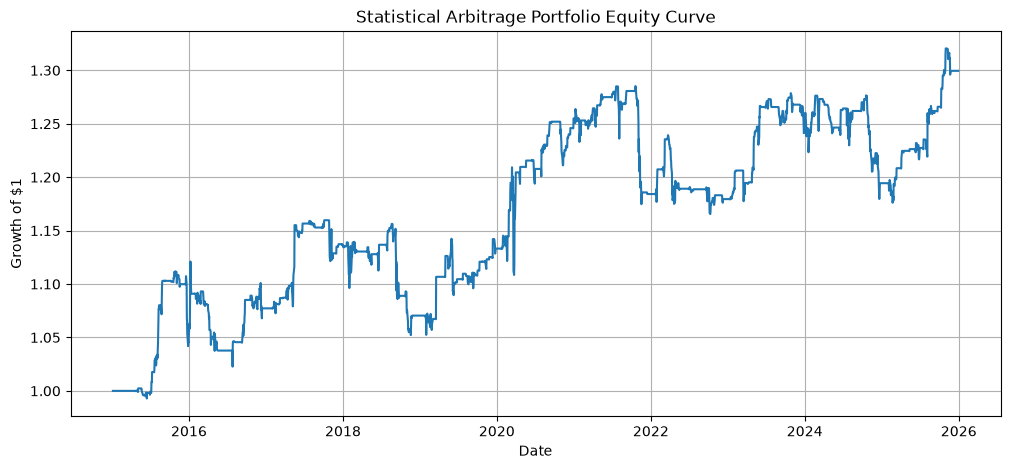

In [71]:
import matplotlib.pyplot as plt


equity_curve = (
    (1 + portfolio_returns)
    .cumprod()
)


plt.figure(figsize=(12,5))

plt.plot(
    equity_curve
)

plt.title(
    "Statistical Arbitrage Portfolio Equity Curve"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Growth of $1"
)

plt.grid()

plt.show()

In [72]:
cost_results = []


for c in [0.0005,0.001,0.002]:

    net_returns = apply_transaction_costs(
        portfolio_returns,
        portfolio_positions,
        cost=c
    )

    result = performance_summary(
        net_returns
    )

    result["Cost"] = c

    cost_results.append(result)


cost_analysis = pd.concat(
    cost_results,
    ignore_index=True
)


cost_analysis

,Total Return,Sharpe Ratio,Max Drawdown,Cost
0,0.173701,0.249836,-0.115941,0.0005
1,0.060046,0.112582,-0.146101,0.0010
2,-0.135358,-0.164268,-0.256309,0.0020


In [73]:
cost_analysis.to_csv(
    "../data/transaction_cost_analysis.csv",
    index=False
)